In [1]:
from src.data_loader import load_categories, save_raw, load_raw, raw_data_exists
from src.preprocessing import preprocess, save_processed, load_processed, processed_data_exists
from src.sentiment import load_model, predict, filter_low_confidence, save_with_sentiment, load_with_sentiment, sentiment_data_exists
from src.mismatch import classify, summary, summary_by_rating, sample_mismatches, save_classified, load_classified, classified_data_exists
from src.analysis import plot_mismatch_by_category, plot_mismatch_by_rating, plot_mismatch_direction, save_summary_tables, qualitative_table
from src.analysis import sentiment_confusion_matrix, chi_square_category_test, chi_square_rating_test, confidence_comparison, mismatch_direction_table, review_length_analysis

from IPython.display import display
import pandas as pd

In [2]:
FORCE_RELOAD = False

In [3]:
if (not raw_data_exists() or FORCE_RELOAD):
	df_raw = load_categories(["Electronics", "Clothing", "Books", "Home_and_Kitchen", "Sports_and_Outdoors", "Automotive"], n_samples_per_category=5000)
	save_raw(df_raw)
else:
	print("Raw data already exists. Skipping streaming step.")
	df_raw = load_raw()

Raw data already exists. Skipping streaming step.
Loaded 30,000 reviews from data/raw/reviews_raw.parquet


In [4]:
if (not processed_data_exists() or FORCE_RELOAD):
	df_clean = preprocess(df_raw)
	save_processed(df_clean)
else:
	print("Processed data already exists. Skipping preprocessing step.")
	df_clean = load_processed()

Processed data already exists. Skipping preprocessing step.
Loaded 9,862 processed reviews from data/processed/reviews_processed.parquet


In [5]:
if (not sentiment_data_exists() or FORCE_RELOAD):
	classifier = load_model()
	df_sentiment = predict(df_clean, classifier)
	df_sentiment = filter_low_confidence(df_sentiment, threshold=0.60)
	save_with_sentiment(df_sentiment)
else:
	print("Sentiment data already exists. Skipping sentiment analysis step.")
	df_sentiment = load_with_sentiment()

Sentiment data already exists. Skipping sentiment analysis step.
Loaded 8,391 reviews with sentiment from data/processed/reviews_with_sentiment.parquet


In [6]:
if (not classified_data_exists() or FORCE_RELOAD):
	df_classified = classify(df_sentiment)
	save_classified(df_classified)
else:
	print("Classified data already exists. Skipping classification step.")
	df_classified = load_classified()

Classified data already exists. Skipping classification step.
Loaded 8,391 classified reviews from data/processed/reviews_with_mismatch.parquet


Saved figure → results/figures/mismatch_by_category.png / .pdf
Saved figure → results/figures/mismatch_by_rating.png / .pdf


/Users/vicvsl/dev/tudelft/WebSciEng/src/analysis.py:329: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.tight_layout()
/Users/vicvsl/dev/tudelft/WebSciEng/src/analysis.py:82: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.savefig(out, bbox_inches="tight")


Saved figure → results/figures/mismatch_direction_by_category.png / .pdf
Saved summary_by_category  → results/tables
Saved summary_by_rating    → results/tables


,category,Stars,Rating sentiment,Text sentiment,Confidence,Direction,Review excerpt
0,Home_and_Kitchen,4.0,positive,negative,0.6453,text_more_negative,"I really love this item, but it has a couple o..."
1,Books,5.0,positive,negative,0.9094,text_more_negative,"Great stories, but hated when he was making he..."
2,Home_and_Kitchen,5.0,positive,negative,0.6728,text_more_negative,I will never buy another ice tray than this on...
3,Automotive,4.0,positive,negative,0.8196,text_more_negative,The look is very deceiving. These are cheap gl...
4,Electronics,1.0,negative,positive,0.9075,text_more_positive,"Used it first time today, found my course imme..."
5,Sports_and_Outdoors,2.0,negative,positive,0.9359,text_more_positive,Ordered this jacket for a great price. The col...
6,Automotive,4.0,positive,negative,0.8674,text_more_negative,This was supposed to fit a Nissan Sentra but i...
7,Electronics,1.0,negative,positive,0.9481,text_more_positive,"Absolutely loved the color, feel, and clasp me..."
8,Books,2.0,negative,positive,0.9046,text_more_positive,This one was ok- mostly gave suggestions versu...
9,Sports_and_Outdoors,1.0,negative,positive,0.9281,text_more_positive,"The idea behind these are great. However, the ..."


/Users/vicvsl/dev/tudelft/WebSciEng/.venv/lib/python3.14/site-packages/IPython/core/events.py:100: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  func(*args, **kwargs)


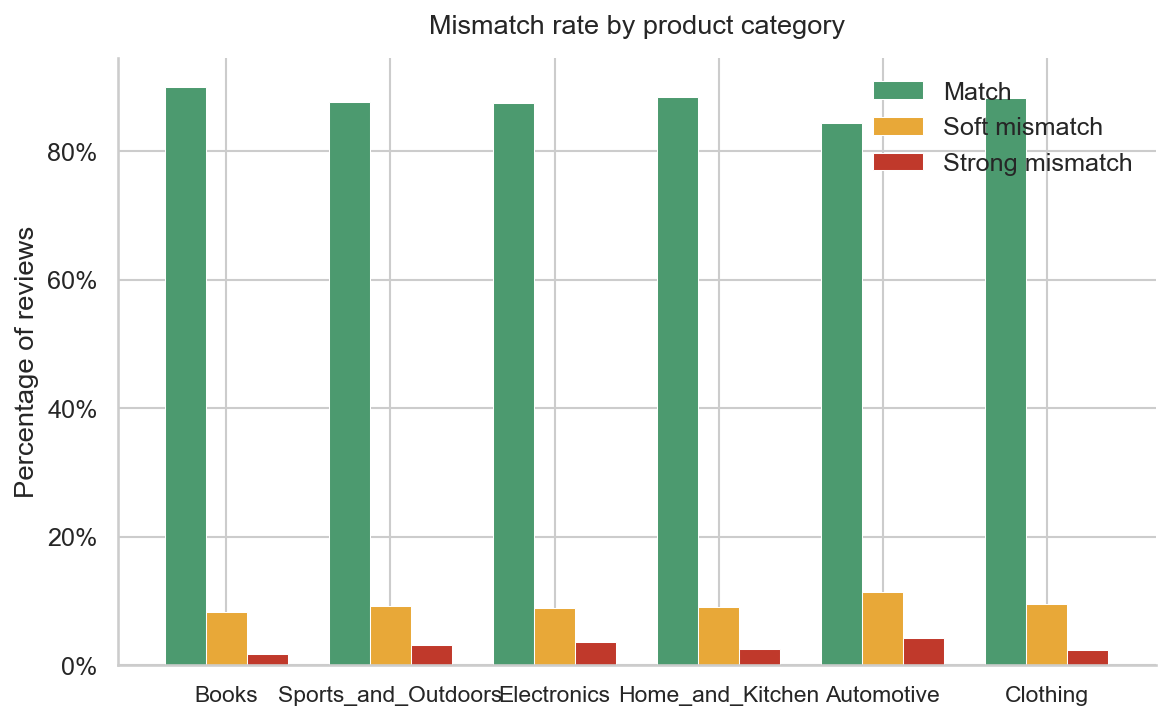

/Users/vicvsl/dev/tudelft/WebSciEng/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


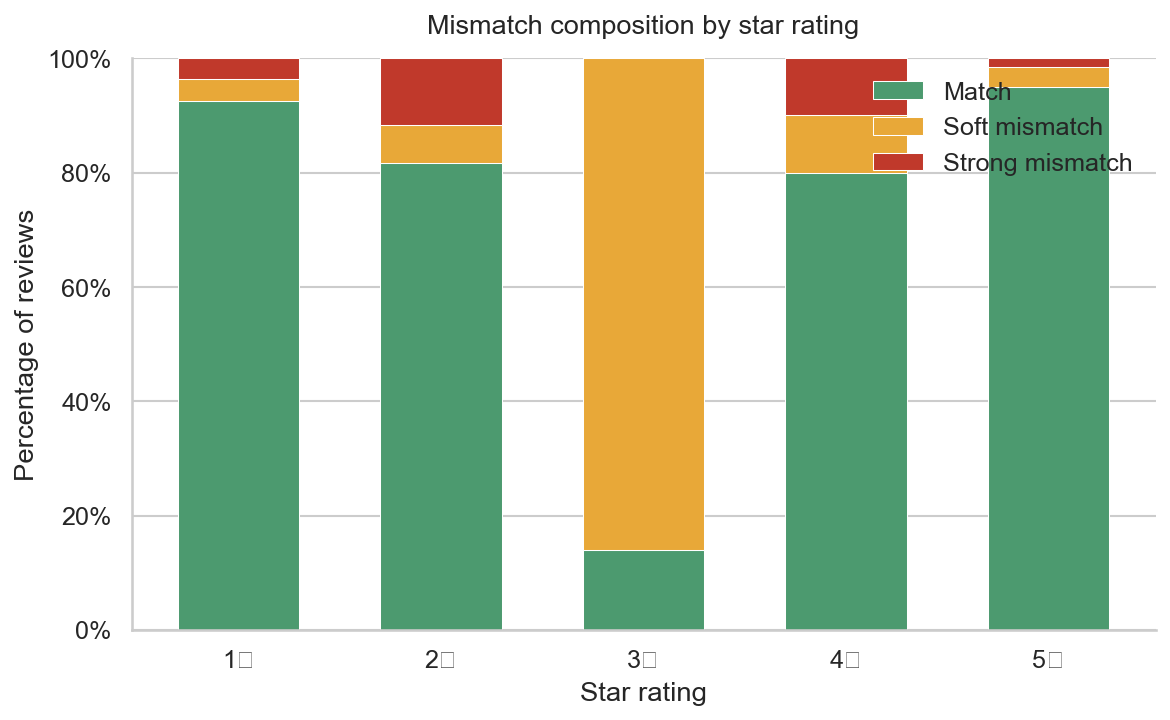

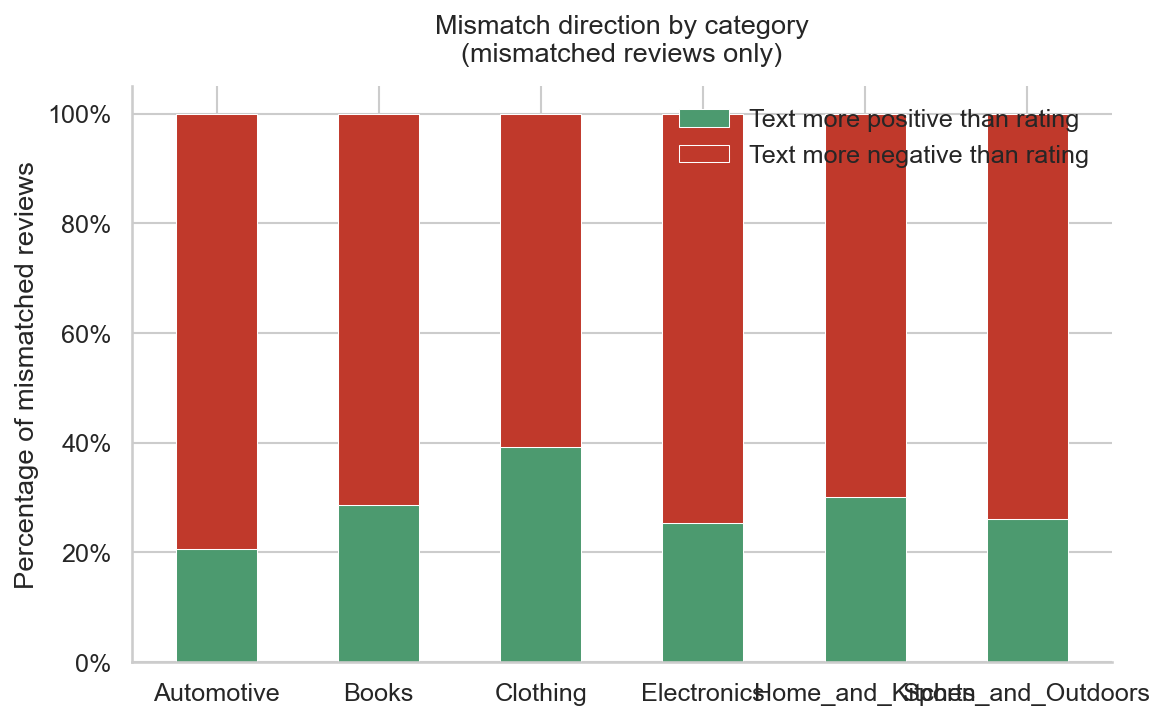

In [7]:
df = df_classified.copy()
plot_mismatch_by_category(df)
plot_mismatch_by_rating(df)
plot_mismatch_direction(df)
save_summary_tables(df)
qualitative_table(df)

In [8]:
print("CONFUSION MATRIX")
cm = sentiment_confusion_matrix(df)
display(cm)

print("CHI-SQUARE TEST: CATEGORY vs MISMATCH")
cat_stats = chi_square_category_test(df)
print(f"Chi-square : {cat_stats['chi2']:.4f}")
print(f"Degrees freedom : {cat_stats['dof']}")
print(f"P-value : {cat_stats['p']:.6f}")
print(f"Cramér's V : {cat_stats['cramers_v']:.4f}")
if cat_stats["p"] < 0.05:
    print("Result: Significant relationship between category and mismatch rate.")
else:
    print("Result: No significant relationship detected.")

print("CHI-SQUARE TEST: STAR RATING vs MISMATCH")
rating_stats = chi_square_rating_test(df)
print(f"Chi-square : {rating_stats['chi2']:.4f}")
print(f"Degrees freedom : {rating_stats['dof']}")
print(f"P-value : {rating_stats['p']:.6f}")
print(f"Cramér's V : {rating_stats['cramers_v']:.4f}")
if rating_stats["p"] < 0.05:
    print("Result: Significant relationship between rating and mismatch rate.")
else:
    print("Result: No significant relationship detected.")

print("CONFIDENCE SCORE COMPARISON")
conf = confidence_comparison(df)
print(f"Match mean confidence     : {conf['match_mean']:.4f}")
print(f"Mismatch mean confidence : {conf['mismatch_mean']:.4f}")
print(f"Mann-Whitney U           : {conf['u_statistic']:.4f}")
print(f"P-value                  : {conf['p']:.6f}")

print("MISMATCH DIRECTION BY CATEGORY (%)")
direction_table = mismatch_direction_table(df)
display(direction_table)

print("REVIEW LENGTH ANALYSIS")
length_stats = review_length_analysis(df)
print(f"Mean match length     : {length_stats['match_mean_length']:.2f} words")
print(f"Mean mismatch length  : {length_stats['mismatch_mean_length']:.2f} words")
print(f"Mann-Whitney U        : {length_stats['u_statistic']:.4f}")
print(f"P-value               : {length_stats['p']:.6f}")

summary = pd.DataFrame([
    {
        "Test": "Category vs Mismatch",
        "Statistic": cat_stats["chi2"],
        "p-value": cat_stats["p"],
        "Effect size": cat_stats["cramers_v"],
    },
    {
        "Test": "Rating vs Mismatch",
        "Statistic": rating_stats["chi2"],
        "p-value": rating_stats["p"],
        "Effect size": rating_stats["cramers_v"],
    },
])
display(summary.round(4))
summary.to_latex(
    "results/tables/statistical_tests.tex",
    index=False,
    float_format="%.4f"
)

CONFUSION MATRIX


text_sentiment,negative,neutral,positive
rating_sentiment,,,
negative,88.65,4.78,6.57
neutral,54.60,13.89,31.51
positive,2.79,4.48,92.74


CHI-SQUARE TEST: CATEGORY vs MISMATCH
Chi-square : 22.4335
Degrees freedom : 5
P-value : 0.000433
Cramér's V : 0.0517
Result: Significant relationship between category and mismatch rate.
CHI-SQUARE TEST: STAR RATING vs MISMATCH
Chi-square : 2892.5741
Degrees freedom : 4
P-value : 0.000000
Cramér's V : 0.5871
Result: Significant relationship between rating and mismatch rate.
CONFIDENCE SCORE COMPARISON
Match mean confidence     : 0.9028
Mismatch mean confidence : 0.7508
Mann-Whitney U           : 6697227.5000
P-value                  : 0.000000
MISMATCH DIRECTION BY CATEGORY (%)


mismatch_direction,text_more_positive,text_more_negative
category,,
Automotive,20.66,79.34
Books,28.57,71.43
Clothing,39.29,60.71
Electronics,25.37,74.63
Home_and_Kitchen,30.16,69.84
Sports_and_Outdoors,26.07,73.93


REVIEW LENGTH ANALYSIS
Mean match length     : 48.40 words
Mean mismatch length  : 72.18 words
Mann-Whitney U        : 3542124.5000
P-value               : 0.000007


,Test,Statistic,p-value,Effect size
0,Category vs Mismatch,22.4335,0.0004,0.0517
1,Rating vs Mismatch,2892.5741,0.0000,0.5871
